### Suggested Ensemble Method: Averaging Regressor

### Imports

In [190]:
# !pip install scikit-learn
# !pip install pycaret

In [191]:
# Data handling & visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Preprocessing & transformations
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Ensemble models
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, VotingClassifier

# Gradient boosting libraries
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimization & utilities
from scipy.stats import randint, uniform
from tqdm.auto import tqdm
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

results_dir = "../results/"


### Load the dataset

In [192]:
data = pd.read_csv("../datasets/student-mat.csv")      # treat '?' as NaN
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [193]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [194]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [195]:
use_features = [
    "studytime",
    "failures",
    "absences",
    "Medu",
    "Fedu",
    "schoolsup",
    "famsup",
    "higher",
    "internet",
    "activities",
    "traveltime",
    "famrel",
    "goout",
    "health",
    "G1",
    "G2",
    "G3"
]

data = data[use_features]

In [196]:
# data.drop(columns=["school", "sex", "address", "famsize", "Pstatus", "guardian", "romantic", "health", "freetime"], inplace=True)

In [197]:
# Renaming columns to remove spaces and special characters for easier access
data.columns = data.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,G3
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,5,6,6
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,5,5,6
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,7,8,10
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,15,14,15
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,6,10,10


In [198]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,395.0,5.708861,8.003096,0.0,0.0,4.0,8.0,75.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
health,395.0,3.554430,1.390303,1.0,3.0,4.0,5.0,5.0
G1,395.0,10.908861,3.319195,3.0,8.0,11.0,13.0,19.0


In [199]:
data["G3"] = data["G3"]*5
data["G2"] = data["G2"]*5
data["G1"] = data["G1"]*5

data.rename(columns={"G3": "final_score"}, inplace=True)
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50


In [ ]:
data["final_grade"] = data["final_score"].apply(lambda x: "PASS" if x >= 40 else "FAIL")
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score,final_grade
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30,FAIL
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30,FAIL
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50,PASS
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75,PASS
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50,PASS


In [201]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
 17  final_grade  395 non-null    object
dtypes: int64(12), object(6)
memory usage: 55.7+ KB


In [202]:
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score,final_grade
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30,FAIL
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30,FAIL
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50,PASS
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75,PASS
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50,PASS


In [203]:
categorical_cols = data.select_dtypes(include="object")
categorical_cols.describe()

,schoolsup,famsup,higher,internet,activities,final_grade
count,395,395,395,395,395,395
unique,2,2,2,2,2,2
top,no,yes,yes,yes,yes,PASS
freq,344,242,375,329,201,325


In [204]:
categorical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   schoolsup    395 non-null    object
 1   famsup       395 non-null    object
 2   higher       395 non-null    object
 3   internet     395 non-null    object
 4   activities   395 non-null    object
 5   final_grade  395 non-null    object
dtypes: object(6)
memory usage: 18.6+ KB


In [205]:
categorical_cols.head()

,schoolsup,famsup,higher,internet,activities,final_grade
0,yes,no,yes,no,no,FAIL
1,no,yes,yes,yes,no,FAIL
2,yes,no,yes,yes,no,PASS
3,no,yes,yes,yes,yes,PASS
4,no,yes,yes,no,no,PASS


In [206]:
numerical_cols = data.select_dtypes(include=np.number)
numerical_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,395.0,5.708861,8.003096,0.0,0.0,4.0,8.0,75.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
health,395.0,3.554430,1.390303,1.0,3.0,4.0,5.0,5.0
G1,395.0,54.544304,16.595973,15.0,40.0,55.0,65.0,95.0


In [207]:
numerical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   studytime    395 non-null    int64
 1   failures     395 non-null    int64
 2   absences     395 non-null    int64
 3   Medu         395 non-null    int64
 4   Fedu         395 non-null    int64
 5   traveltime   395 non-null    int64
 6   famrel       395 non-null    int64
 7   goout        395 non-null    int64
 8   health       395 non-null    int64
 9   G1           395 non-null    int64
 10  G2           395 non-null    int64
 11  final_score  395 non-null    int64
dtypes: int64(12)
memory usage: 37.2 KB


In [208]:
numerical_cols.head()

,studytime,failures,absences,Medu,Fedu,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,2,4,4,3,25,30,30
1,2,0,4,1,1,1,5,3,3,25,25,30
2,2,3,10,1,1,1,4,2,3,35,40,50
3,3,0,2,4,2,1,3,2,5,75,70,75
4,2,0,4,3,3,1,4,2,5,30,50,50


### Exploratory Data Analysis

In [209]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
 17  final_grade  395 non-null    object
dtypes: int64(12), object(6)
memory usage: 55.7+ KB


In [210]:
data.describe(exclude=np.number).T

,count,unique,top,freq
schoolsup,395,2,no,344
famsup,395,2,yes,242
higher,395,2,yes,375
internet,395,2,yes,329
activities,395,2,yes,201
final_grade,395,2,PASS,325


In [211]:
for col in categorical_cols.columns:
    print(f"Value counts for {col}:")
    print(categorical_cols[col].value_counts())
    print("\n")

Value counts for schoolsup:
schoolsup
no     344
yes     51
Name: count, dtype: int64


Value counts for famsup:
famsup
yes    242
no     153
Name: count, dtype: int64


Value counts for higher:
higher
yes    375
no      20
Name: count, dtype: int64


Value counts for internet:
internet
yes    329
no      66
Name: count, dtype: int64


Value counts for activities:
activities
yes    201
no     194
Name: count, dtype: int64


Value counts for final_grade:
final_grade
PASS    325
FAIL     70
Name: count, dtype: int64




In [212]:
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score,final_grade
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30,FAIL
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30,FAIL
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50,PASS
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75,PASS
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50,PASS


In [213]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
 17  final_grade  395 non-null    object
dtypes: int64(12), object(6)
memory usage: 55.7+ KB


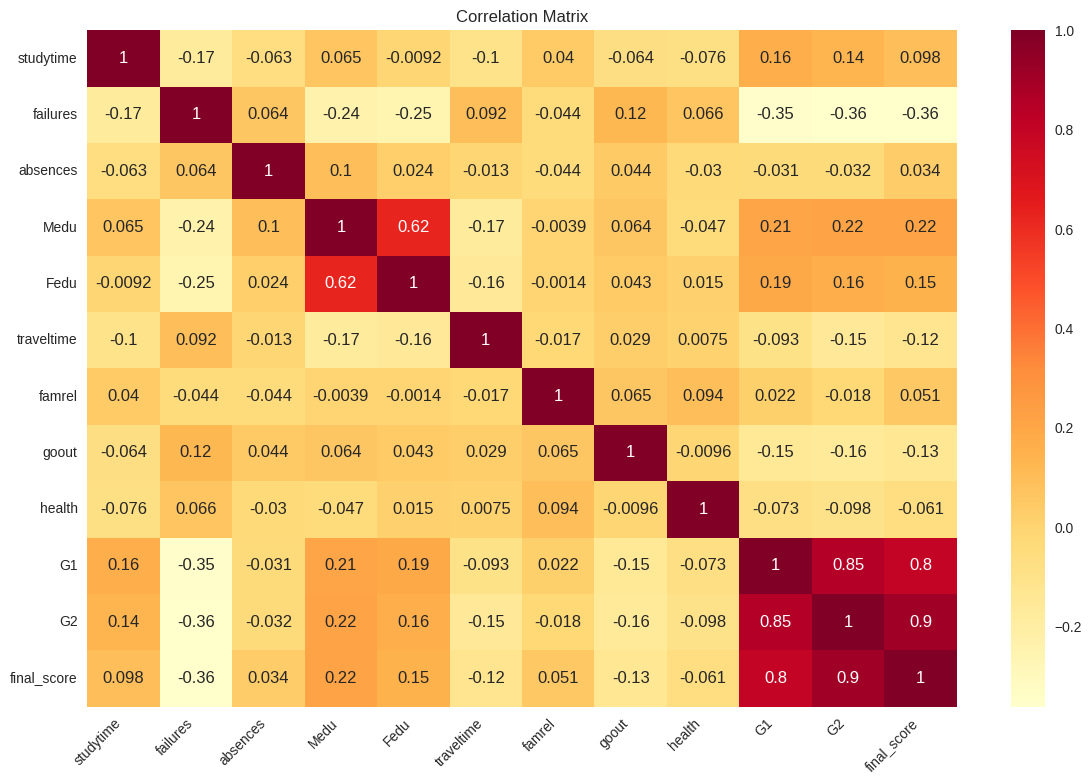

In [214]:
# Correlation Analysis
columns = data.select_dtypes(include=np.number).columns
correlation_matrix = data[columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlOrRd")
plt.xticks(rotation=45, ha="right")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(results_dir + "correlation_analysis.png", dpi=400)
plt.show()

In [215]:

# # fig, ax = plt.subplots()
# # ax.pie(sizes, labels=labels)
# # fig, ax = plt.subplots()

# plt.pie(data["final_grade"].value_counts().values, labels=data["final_grade"].final_grade.value_counts().index, autopct='%.0f%%',
#        textprops={'size': 'smaller'}, radius=0.5)
# plt.show()

In [216]:
grade_count = data.final_grade.value_counts().values
grade_labels = data.final_grade.value_counts().index
grade_labels

Index(['PASS', 'FAIL'], dtype='object', name='final_grade')

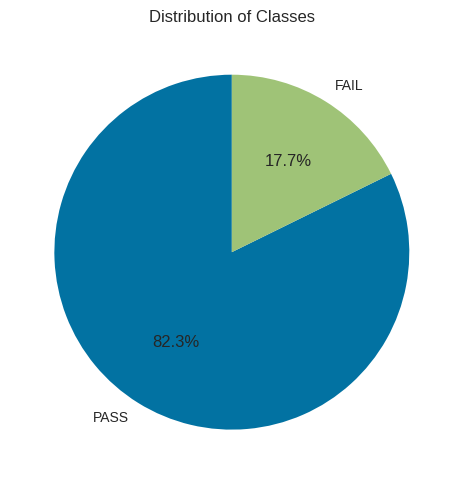

In [217]:
# Create pie chart
plt.figure(figsize=(6, 5))
plt.pie(
    grade_count,
    labels=grade_labels,
    autopct='%1.1f%%',
    startangle=90,
)
plt.title("Distribution of Classes")
plt.tight_layout()
plt.savefig(results_dir + "class_distribution_pie.png", dpi=400)
plt.show()

### Bar Plots

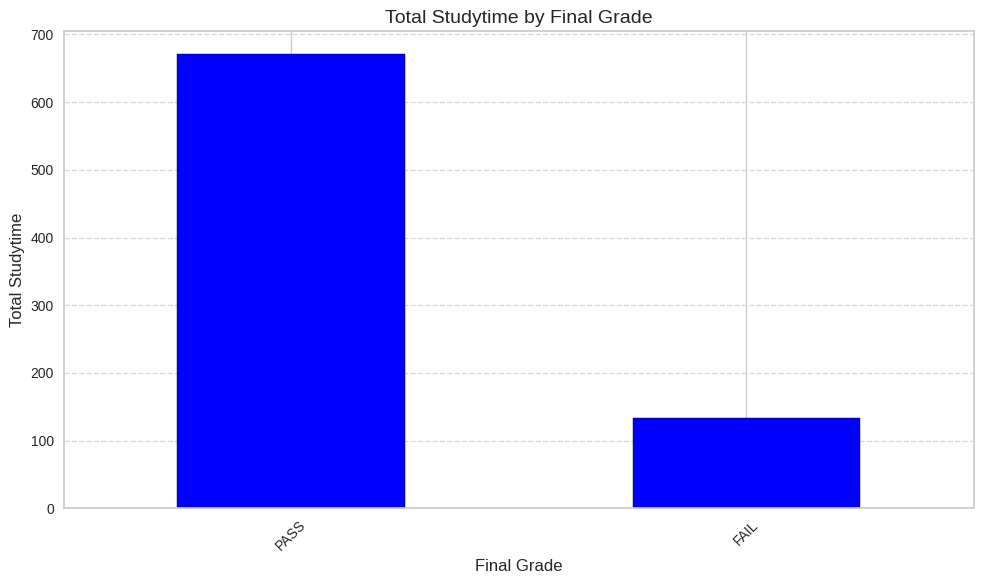

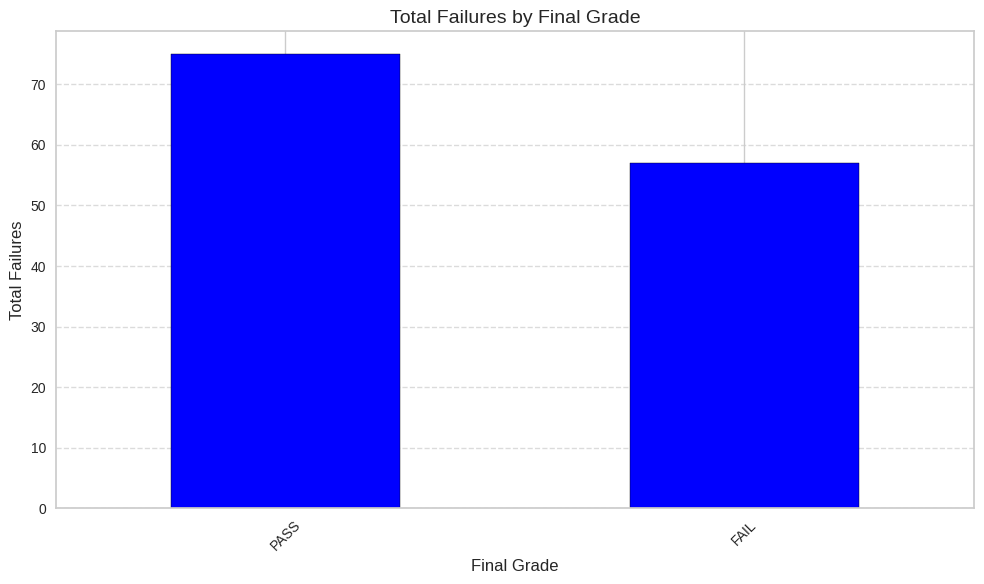

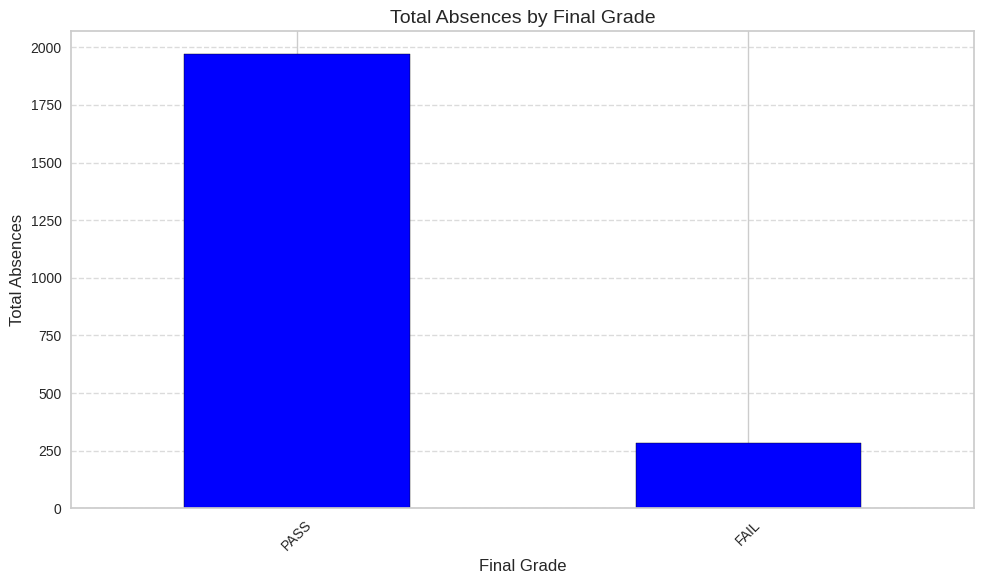

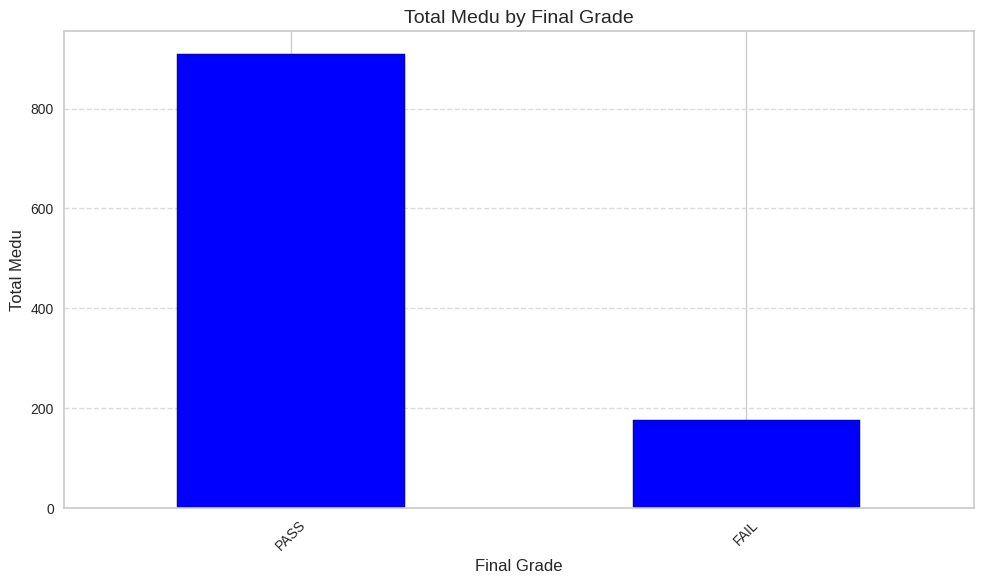

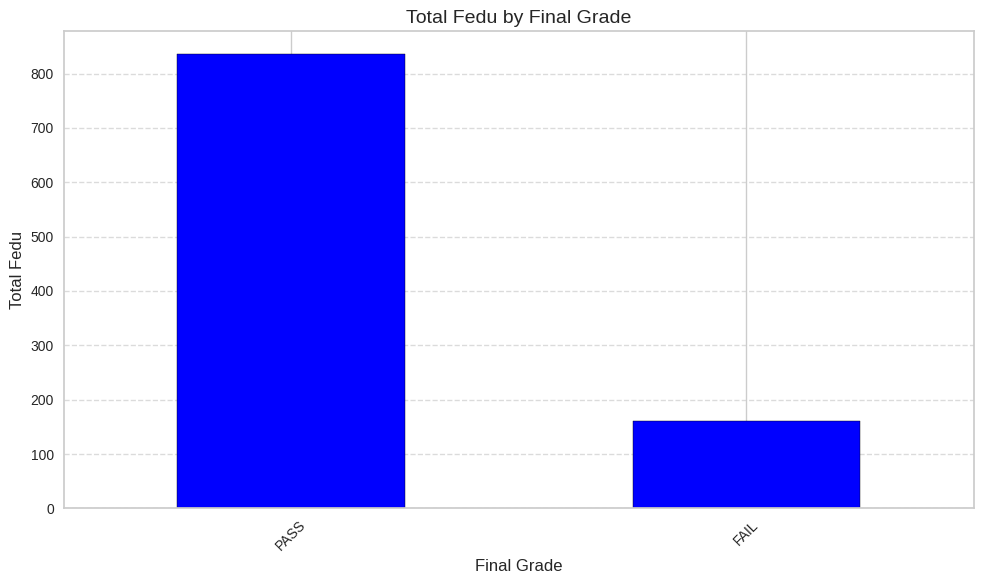

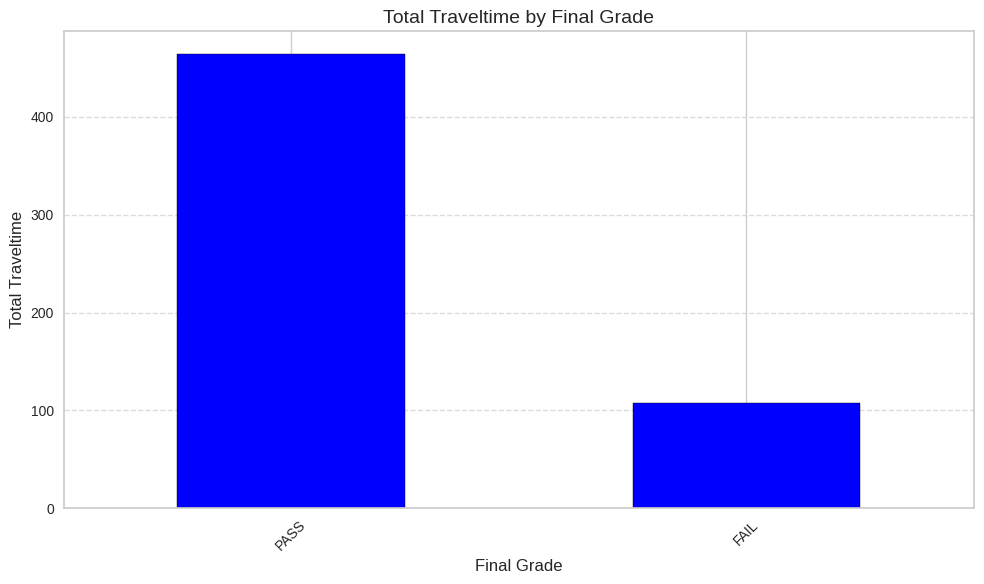

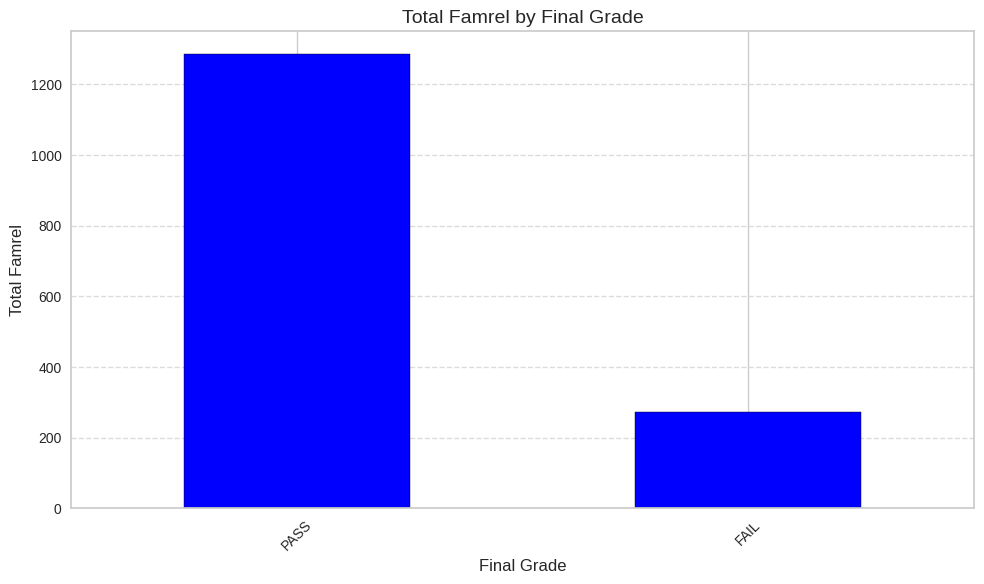

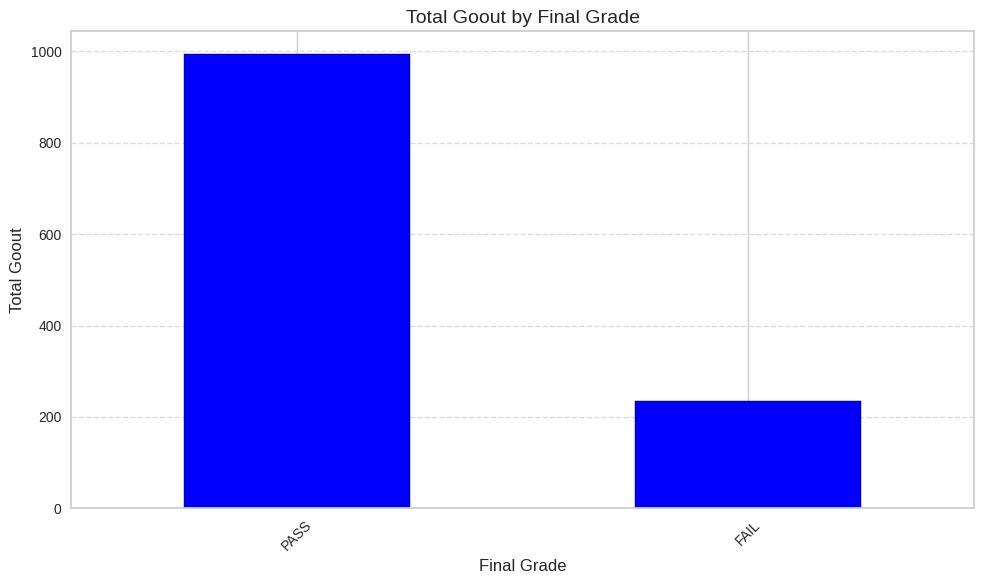

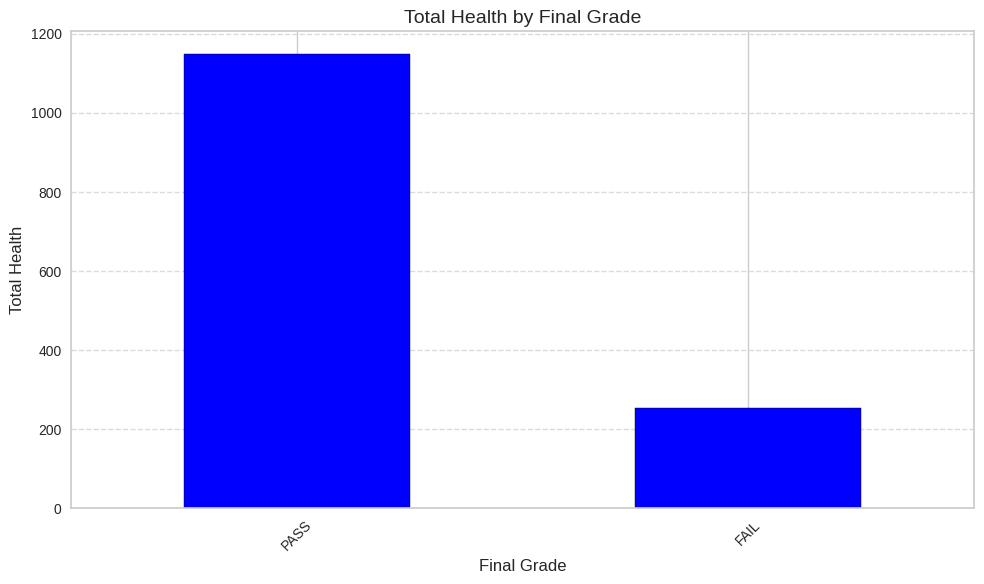

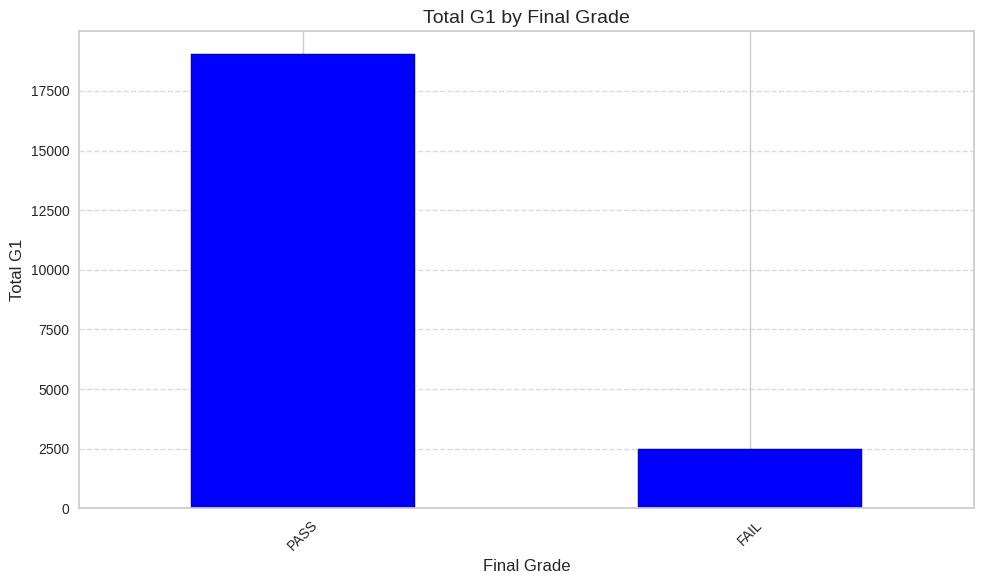

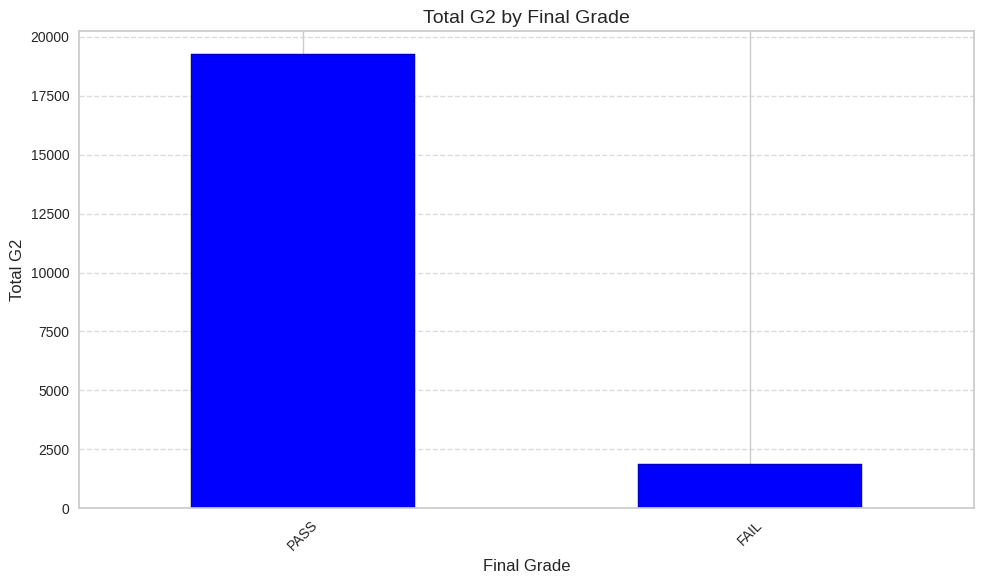

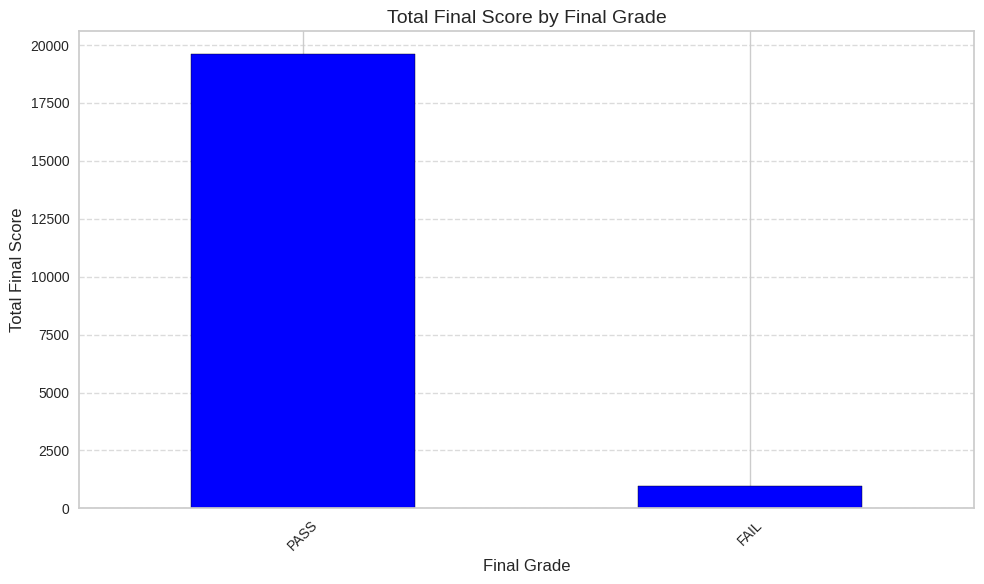

In [218]:
for col in numerical_cols:
    
    total_values = data.groupby("final_grade")[col].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    total_values.plot(kind='bar', color='blue', edgecolor='black')
    
    plt.title(f"Total {col.replace('_',' ').title()} by Final Grade", fontsize=14)
    plt.xlabel("Final Grade", fontsize=12)
    plt.ylabel(f"Total {col.replace('_',' ').title()}", fontsize=12)
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    plt.savefig(results_dir + f"total_{col}_by_final_grade.png", dpi=400)
    plt.show()


In [219]:
numerical_cols = data.describe().columns
numerical_cols

Index(['studytime', 'failures', 'absences', 'Medu', 'Fedu', 'traveltime',
       'famrel', 'goout', 'health', 'G1', 'G2', 'final_score'],
      dtype='object')

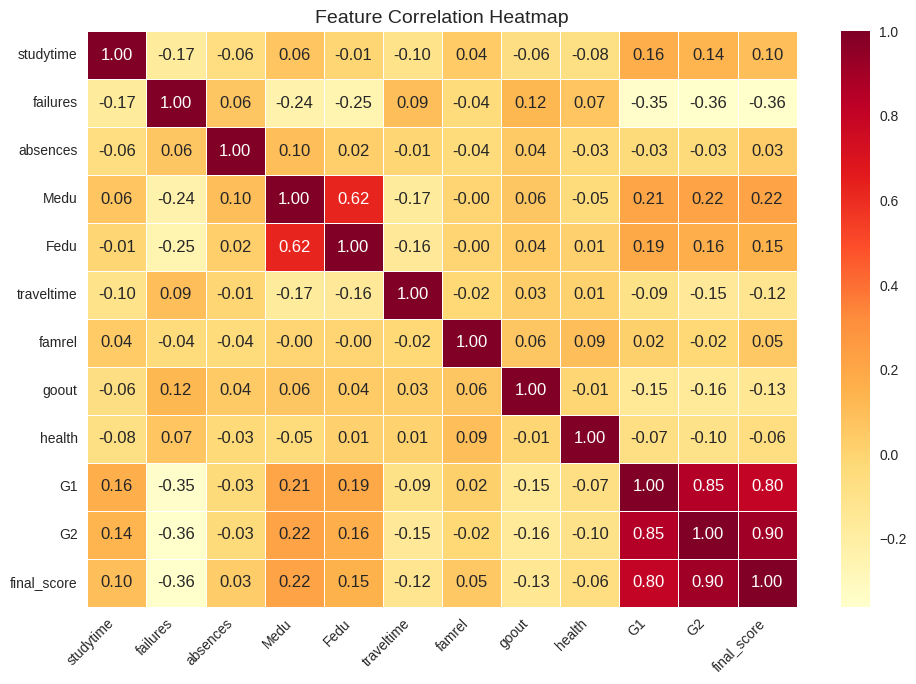

In [220]:
# Heatmap – Correlation Matrix
plt.figure(figsize=(10, 7))
corr = data[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(results_dir + "07_correlation_heatmap.png", dpi=400)
plt.show()

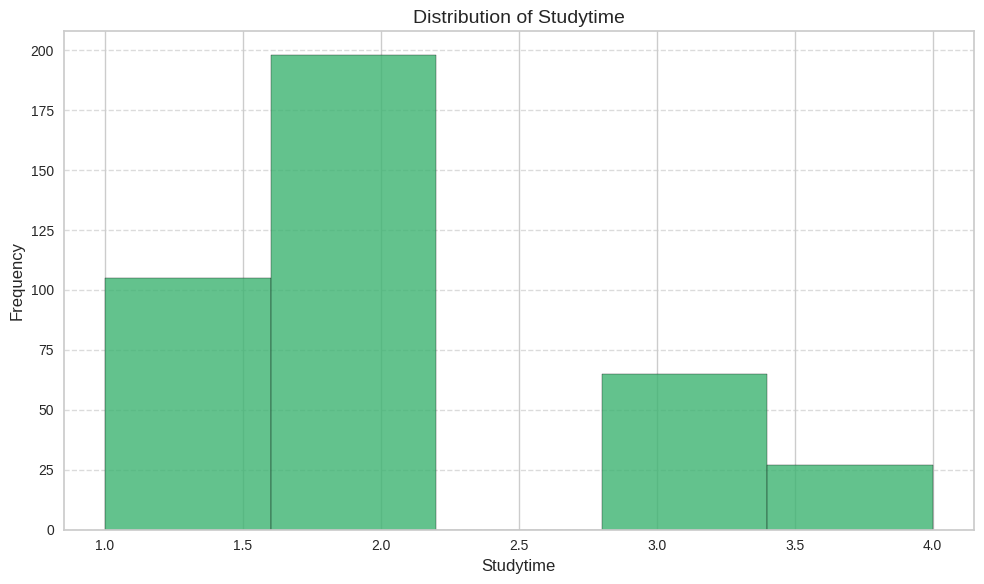

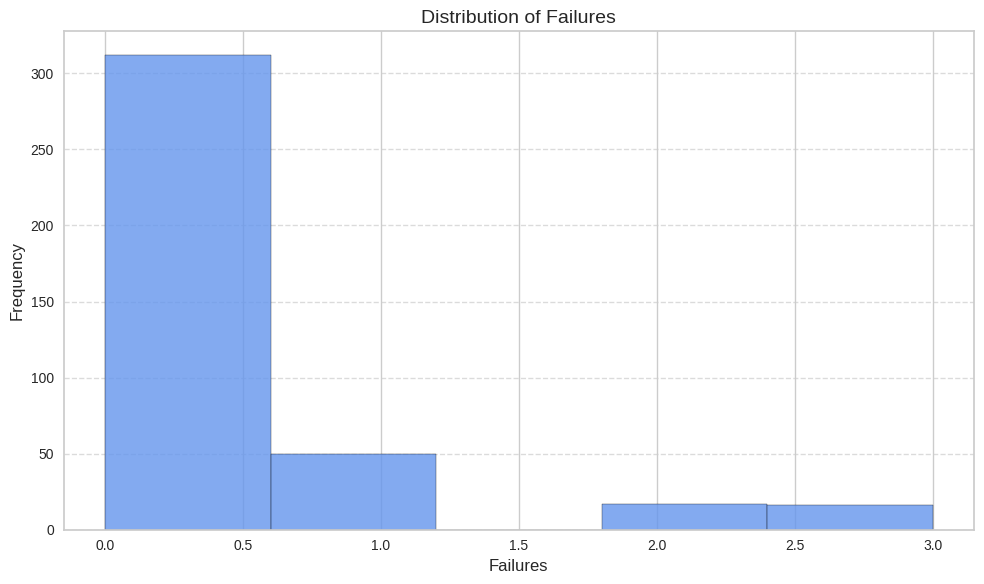

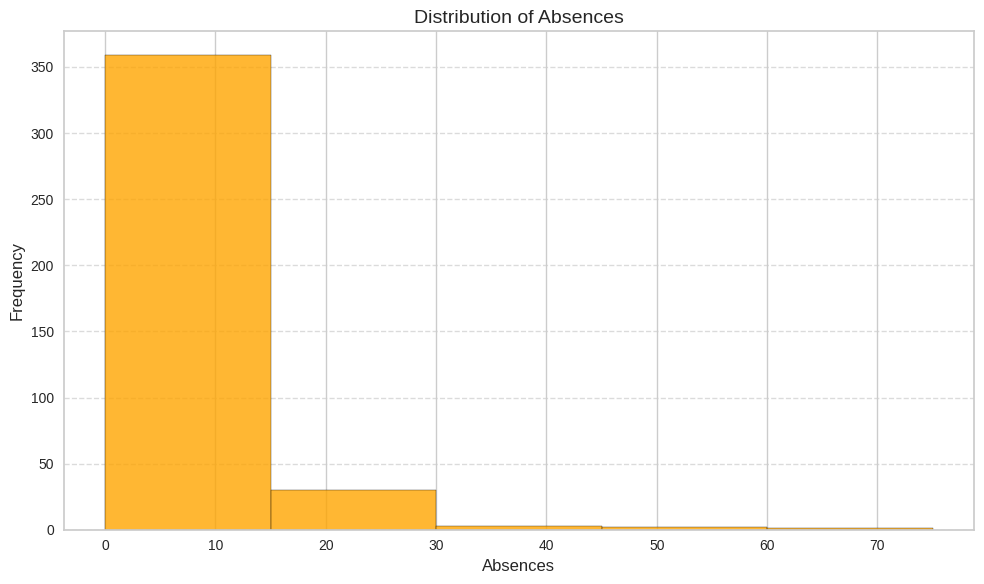

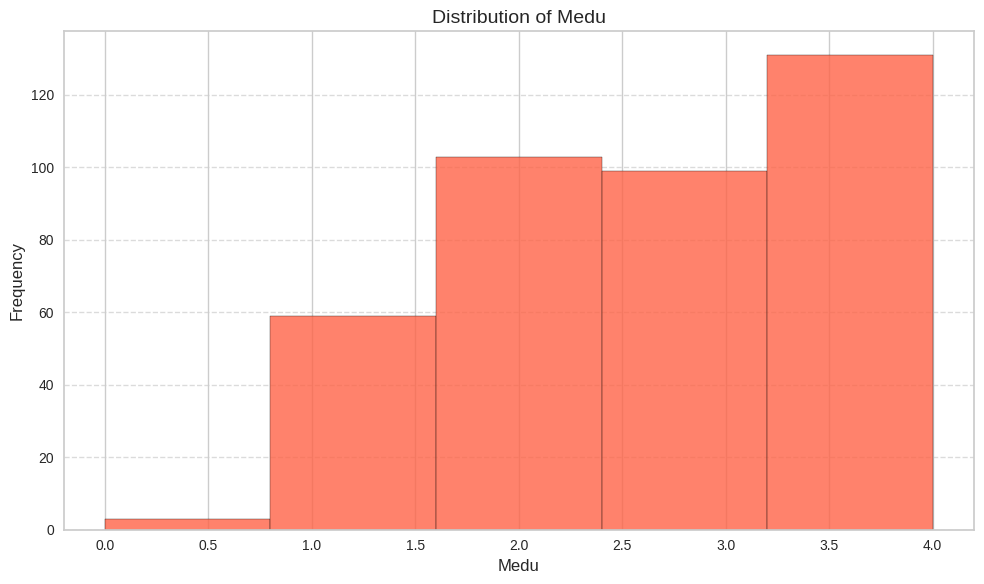

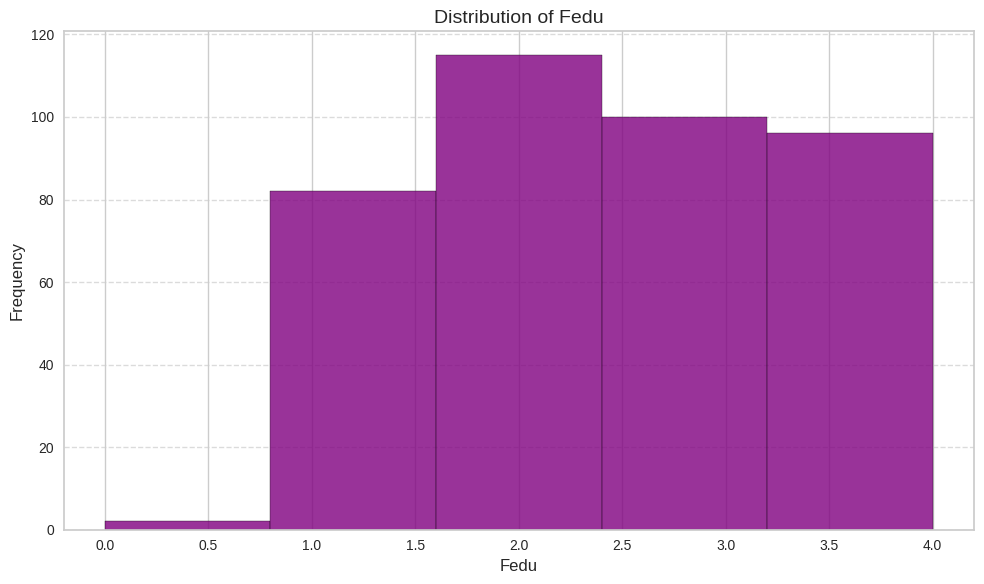

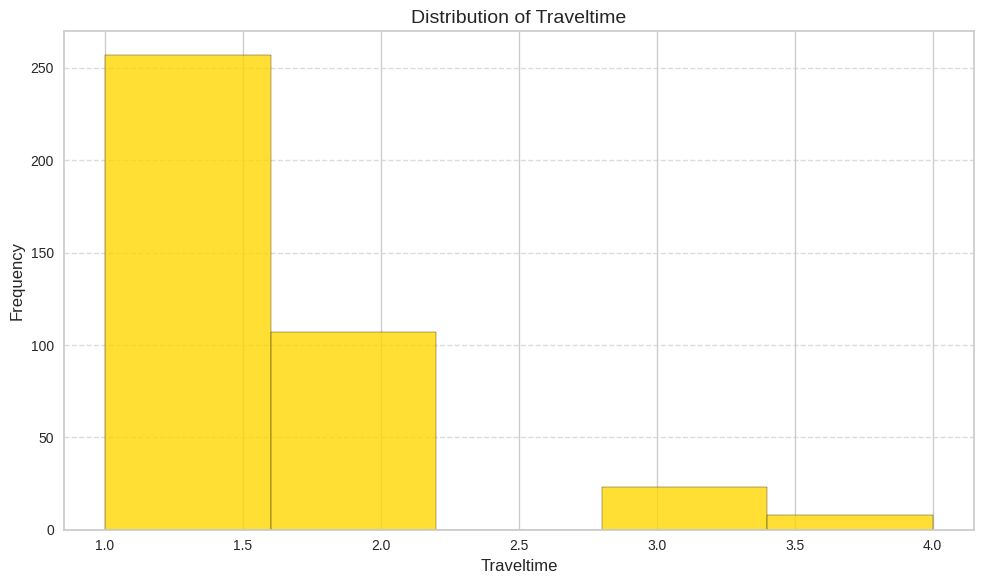

In [221]:
# Histogram Plots

# Different colors for each histogram
colors = [
    "mediumseagreen",
    "cornflowerblue",
    "orange",
    "tomato",
    "purple",
    "gold"
]

for col, color in zip(numerical_cols, colors):

    plt.figure(figsize=(10, 6))
    plt.hist(data[col], bins=5, color=color, edgecolor='black', alpha=0.8)

    plt.title(f"Distribution of {col.replace('_',' ').title()}", fontsize=14)
    plt.xlabel(col.replace('_',' ').title(), fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(results_dir + f"hist_{col}.png", dpi=400)
    plt.show()


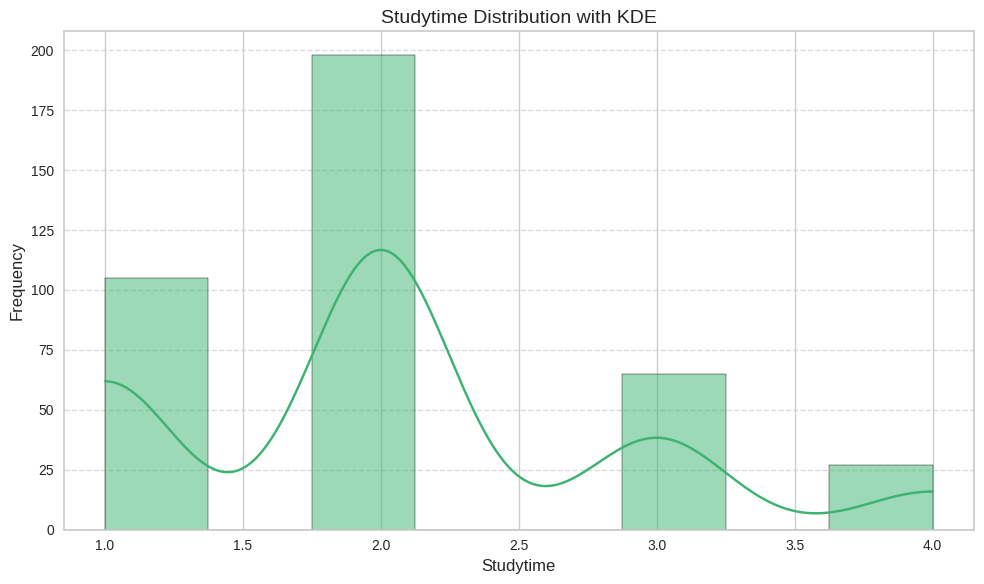

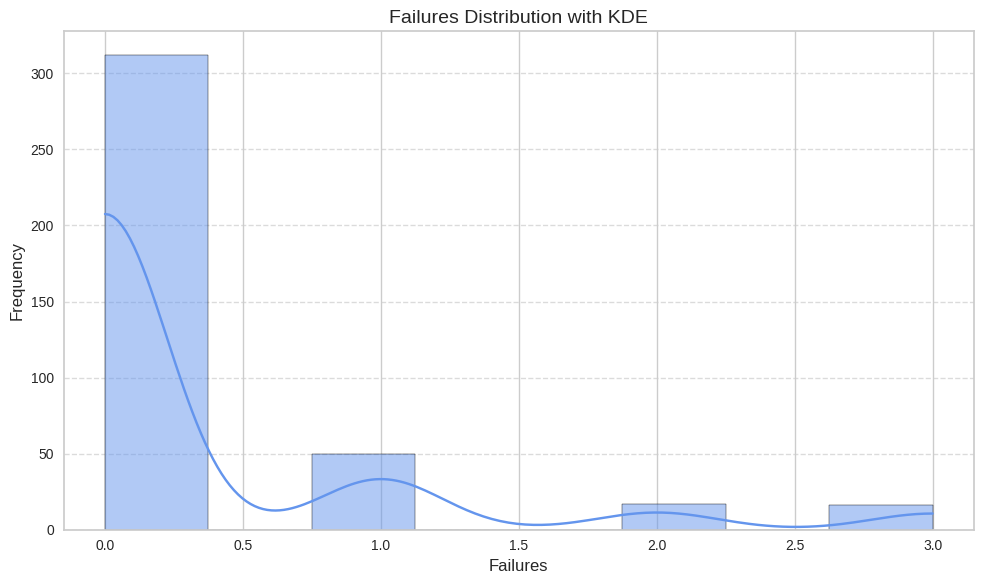

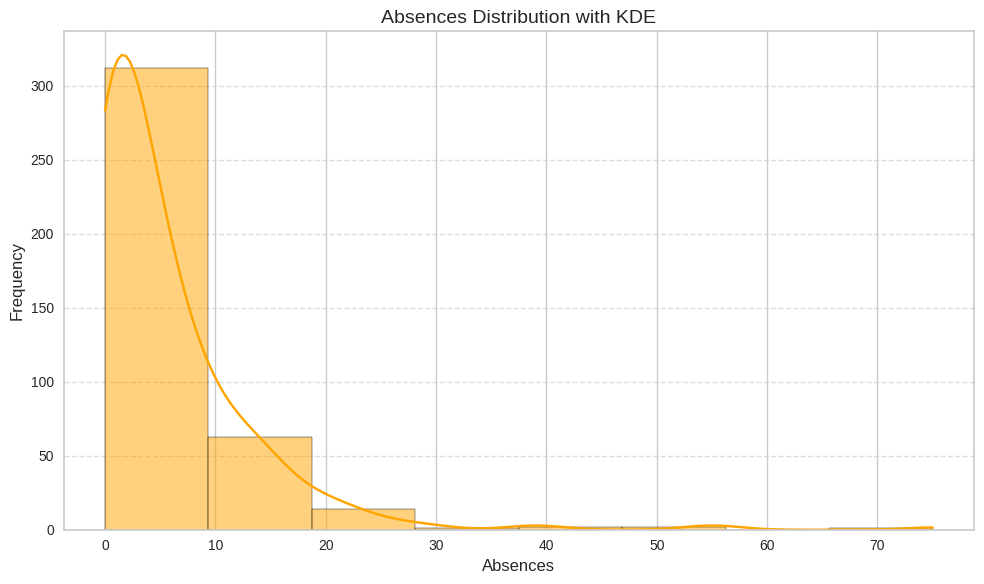

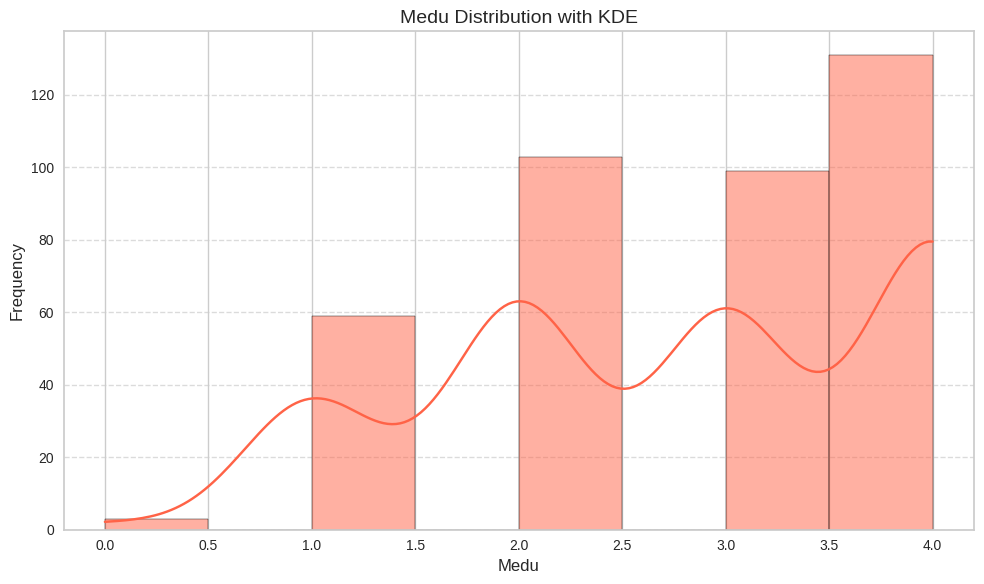

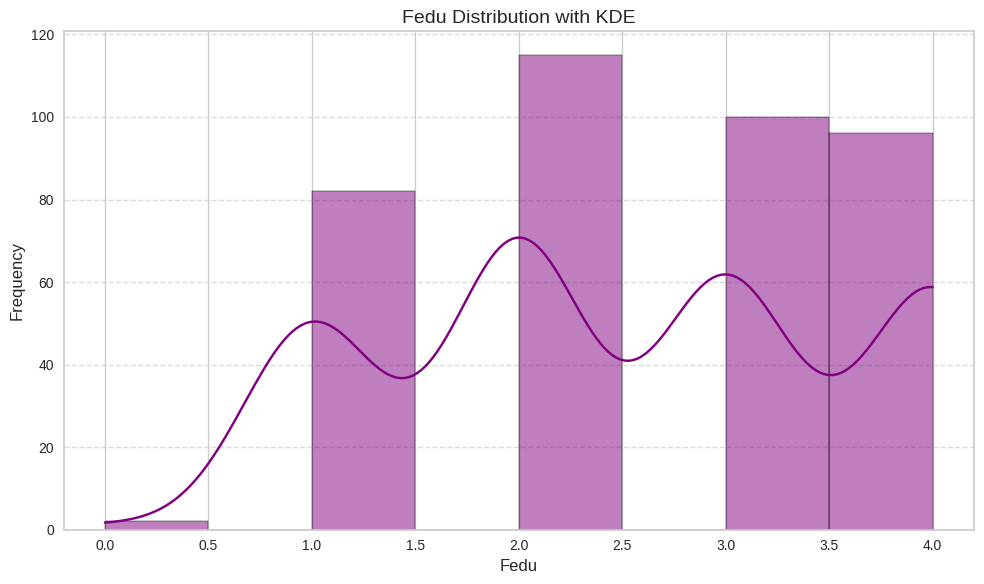

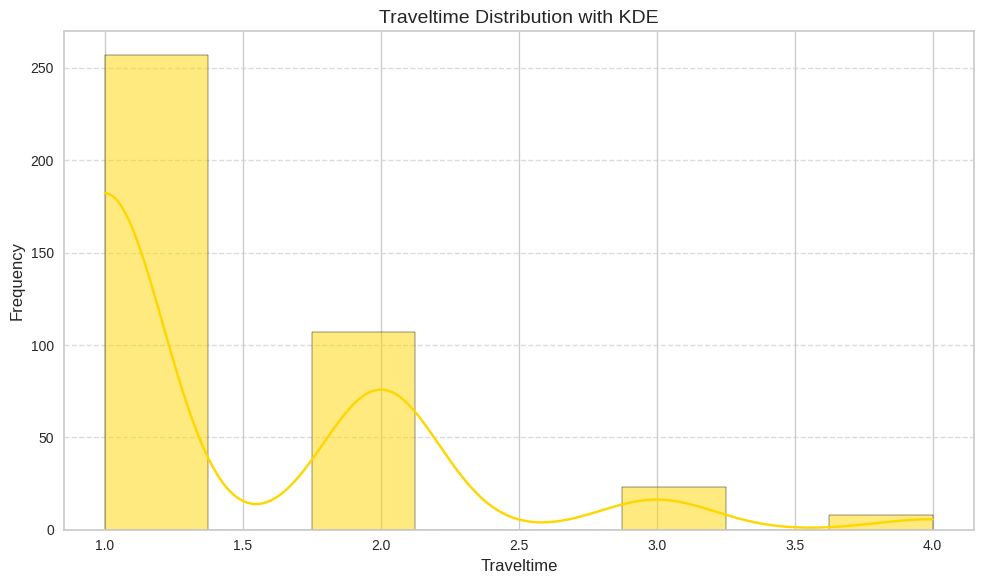

In [222]:
# Histogram Distribution with KDE
for col, color in zip(numerical_cols, colors):

    plt.figure(figsize=(10, 6))
    
    sns.histplot(
        data[col].dropna(),
        kde=True,
        bins=8,
        color=color
    )

    plt.title(f"{col.replace('_',' ').title()} Distribution with KDE", fontsize=14)
    plt.xlabel(col.replace('_',' ').title(), fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(results_dir + f"kde_{col}.png", dpi=400)
    plt.show()


In [223]:
for col in data.columns:
    print(f"\nColumn name: {col}")
    print(f"Unique values in each column: {data[col].unique()}")


Column name: studytime
Unique values in each column: [2 3 1 4]

Column name: failures
Unique values in each column: [0 3 2 1]

Column name: absences
Unique values in each column: [ 6  4 10  2  0 16 14  7  8 25 12 54 18 26 20 56 24 28  5 13 15 22  3 21
  1 75 30 19  9 11 38 40 23 17]

Column name: Medu
Unique values in each column: [4 1 3 2 0]

Column name: Fedu
Unique values in each column: [4 1 2 3 0]

Column name: schoolsup
Unique values in each column: ['yes' 'no']

Column name: famsup
Unique values in each column: ['no' 'yes']

Column name: higher
Unique values in each column: ['yes' 'no']

Column name: internet
Unique values in each column: ['no' 'yes']

Column name: activities
Unique values in each column: ['no' 'yes']

Column name: traveltime
Unique values in each column: [2 1 3 4]

Column name: famrel
Unique values in each column: [4 5 3 1 2]

Column name: goout
Unique values in each column: [4 3 2 1 5]

Column name: health
Unique values in each column: [3 5 1 2 4]

Column nam

In [224]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
 17  final_grade  395 non-null    object
dtypes: int64(12), object(6)
memory usage: 55.7+ KB


In [225]:
data.isnull().sum()

studytime      0
failures       0
absences       0
Medu           0
Fedu           0
schoolsup      0
famsup         0
higher         0
internet       0
activities     0
traveltime     0
famrel         0
goout          0
health         0
G1             0
G2             0
final_score    0
final_grade    0
dtype: int64

In [226]:
data = data.dropna(subset=['final_score'])

In [227]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,395.0,5.708861,8.003096,0.0,0.0,4.0,8.0,75.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
health,395.0,3.554430,1.390303,1.0,3.0,4.0,5.0,5.0
G1,395.0,54.544304,16.595973,15.0,40.0,55.0,65.0,95.0


In [228]:
# data["attendance_rate"].fillna(data["attendance_rate"].mean(), inplace=True)
# data["study_hours_week"].fillna(data["study_hours_week"].mean(), inplace=True)
# data["prev_grade"].fillna(data["prev_grade"].mean(), inplace=True)
# data["extra_activities"].fillna(data["extra_activities"].mode()[0], inplace=True)
# data["study_hours"].fillna(data["study_hours"].mean(), inplace=True)
# data["attendance_pct"].fillna(data["attendance_pct"].mean(), inplace=True)

In [229]:
data = data.drop("final_score", axis=1)

### PyCaret Implementation

In [230]:
from pycaret.classification import *

s = setup(data, target = 'final_grade', session_id = 123)

,Description,Value
0,Session id,123
1,Target,final_grade
2,Target type,Binary
3,Target mapping,"FAIL: 0, PASS: 1"
4,Original data shape,"(395, 17)"
5,Transformed data shape,"(395, 17)"
6,Transformed train set shape,"(276, 17)"
7,Transformed test set shape,"(119, 17)"
8,Numeric features,11
9,Categorical features,5


In [231]:
# compare baseline models
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9385,0.9678,0.9385,0.9397,0.9352,0.7661,0.7788,0.1540
xgboost,Extreme Gradient Boosting,0.9384,0.9607,0.9384,0.9420,0.9390,0.7905,0.7944,0.0380
lightgbm,Light Gradient Boosting Machine,0.9348,0.9550,0.9348,0.9357,0.9323,0.7574,0.7665,0.3790
ada,Ada Boost Classifier,0.9311,0.9495,0.9311,0.9315,0.9289,0.7465,0.7540,0.0270
rf,Random Forest Classifier,0.9276,0.9542,0.9276,0.9301,0.9260,0.7405,0.7500,0.0380
knn,K Neighbors Classifier,0.9241,0.9354,0.9241,0.9270,0.9226,0.7292,0.7389,0.1700
gbc,Gradient Boosting Classifier,0.9206,0.9520,0.9206,0.9242,0.9176,0.7105,0.7241,0.0270
lr,Logistic Regression,0.9204,0.9621,0.9204,0.9256,0.9217,0.7301,0.7342,0.3240
et,Extra Trees Classifier,0.9060,0.9505,0.9060,0.9027,0.9006,0.6438,0.6551,0.0330
lda,Linear Discriminant Analysis,0.9019,0.9412,0.9019,0.9060,0.8943,0.6159,0.6433,0.0130


In [232]:
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_grade
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,FAIL
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,FAIL
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,PASS
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,PASS
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,PASS


In [233]:
data.isnull().sum()

studytime      0
failures       0
absences       0
Medu           0
Fedu           0
schoolsup      0
famsup         0
higher         0
internet       0
activities     0
traveltime     0
famrel         0
goout          0
health         0
G1             0
G2             0
final_grade    0
dtype: int64

In [234]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_grade  395 non-null    object
dtypes: int64(11), object(6)
memory usage: 52.6+ KB


In [235]:
cat_cols = data.select_dtypes(exclude=[np.number]).columns
cat_cols

Index(['schoolsup', 'famsup', 'higher', 'internet', 'activities',
       'final_grade'],
      dtype='object')

In [236]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns to encode
# Initialize a dictionary to store encoders (optional, useful for inverse transform)
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # store encoder for later use if needed

In [237]:
import pickle

# Save the dictionary of label encoders to a pickle file
with open(results_dir + "label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print(f"Label encoders saved to '{results_dir}label_encoders.pkl'")

Label encoders saved to '../results/label_encoders.pkl'


In [238]:
# Separating predictors from target
X = data.drop(["final_grade", "G1", "G2"], axis=1)
y = data["final_grade"]

# Data Splitting
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.0, stratify=y
# )

In [239]:
X_train, X_test, y_train, y_test = X, X, y, y

In [240]:
X_train

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health
0,2,0,6,4,4,1,0,1,0,0,2,4,4,3
1,2,0,4,1,1,0,1,1,1,0,1,5,3,3
2,2,3,10,1,1,1,0,1,1,0,1,4,2,3
3,3,0,2,4,2,0,1,1,1,1,1,3,2,5
4,2,0,4,3,3,0,1,1,0,0,1,4,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,2,2,11,2,2,0,1,1,0,0,1,5,4,4
391,1,0,3,3,1,0,0,1,1,0,2,2,5,2
392,1,3,3,1,1,0,0,1,0,0,1,5,3,3
393,1,0,0,3,2,0,0,1,1,0,3,4,1,5


In [241]:
X_test

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health
0,2,0,6,4,4,1,0,1,0,0,2,4,4,3
1,2,0,4,1,1,0,1,1,1,0,1,5,3,3
2,2,3,10,1,1,1,0,1,1,0,1,4,2,3
3,3,0,2,4,2,0,1,1,1,1,1,3,2,5
4,2,0,4,3,3,0,1,1,0,0,1,4,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,2,2,11,2,2,0,1,1,0,0,1,5,4,4
391,1,0,3,3,1,0,0,1,1,0,2,2,5,2
392,1,3,3,1,1,0,0,1,0,0,1,5,3,3
393,1,0,0,3,2,0,0,1,1,0,3,4,1,5


In [242]:
# Display first 5 rows to check
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_grade
0,2,0,6,4,4,1,0,1,0,0,2,4,4,3,25,30,0
1,2,0,4,1,1,0,1,1,1,0,1,5,3,3,25,25,0
2,2,3,10,1,1,1,0,1,1,0,1,4,2,3,35,40,1
3,3,0,2,4,2,0,1,1,1,1,1,3,2,5,75,70,1
4,2,0,4,3,3,0,1,1,0,0,1,4,2,5,30,50,1


In [243]:
for col in data.columns:
    print(f"\nColumn name: {col}")
    print(f"Unique values in each column: {data[col].unique()}")


Column name: studytime
Unique values in each column: [2 3 1 4]

Column name: failures
Unique values in each column: [0 3 2 1]

Column name: absences
Unique values in each column: [ 6  4 10  2  0 16 14  7  8 25 12 54 18 26 20 56 24 28  5 13 15 22  3 21
  1 75 30 19  9 11 38 40 23 17]

Column name: Medu
Unique values in each column: [4 1 3 2 0]

Column name: Fedu
Unique values in each column: [4 1 2 3 0]

Column name: schoolsup
Unique values in each column: [1 0]

Column name: famsup
Unique values in each column: [0 1]

Column name: higher
Unique values in each column: [1 0]

Column name: internet
Unique values in each column: [0 1]

Column name: activities
Unique values in each column: [0 1]

Column name: traveltime
Unique values in each column: [2 1 3 4]

Column name: famrel
Unique values in each column: [4 5 3 1 2]

Column name: goout
Unique values in each column: [4 3 2 1 5]

Column name: health
Unique values in each column: [3 5 1 2 4]

Column name: G1
Unique values in each column:

In [244]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [245]:
# Save the dictionary of scaler to a pickle file
with open(results_dir + "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"Scaler saved to '{results_dir}scaler.pkl'")

Scaler saved to '../results/scaler.pkl'


In [246]:
import pandas as pd

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    cohen_kappa_score,
    matthews_corrcoef
)

# -------------------------------------------------------
# Define best models
# -------------------------------------------------------

models = {

    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),

    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

# -------------------------------------------------------
# Train and evaluate models
# -------------------------------------------------------

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    kappa = cohen_kappa_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append([
        name,
        acc,
        auc,
        recall,
        precision,
        f1,
        kappa,
        mcc
    ])

# -------------------------------------------------------
# Convert results to DataFrame
# -------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "AUC",
        "Recall",
        "Precision",
        "F1",
        "Kappa",
        "MCC"
    ]
)

# Sort by Accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)


[LightGBM] [Info] Number of positive: 325, number of negative: 70
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 395, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.822785 -> initscore=1.535330
[LightGBM] [Info] Start training from score 1.535330
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [247]:
results_df

,Model,Accuracy,AUC,Recall,Precision,F1,Kappa,MCC
1,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,RandomForest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,LightGBM,0.992405,0.999824,1.000000,0.990854,0.995406,0.973511,0.973852
0,CatBoost,0.964557,0.998813,1.000000,0.958702,0.978916,0.868114,0.875763
3,AdaBoost,0.853165,0.846593,0.969231,0.867769,0.915698,0.360235,0.396772


In [248]:
from sklearn.ensemble import VotingClassifier

# Ensemble model using top performing classifiers
ensemble_model = VotingClassifier(

    estimators=[

        ('catboost', models["CatBoost"]),
        ('xgboost', models["XGBoost"]),
        ('lightgbm', models["LightGBM"]),
        ('adaboost', models["AdaBoost"]),
        ('randomforest', models["RandomForest"])

    ],

    voting='soft'  # probability averaging

)


In [249]:
# Example: train and evaluate
ensemble_model.fit(X_train, y_train)
y_pred = ensemble_model.predict(X_test)

[LightGBM] [Info] Number of positive: 325, number of negative: 70
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 84
[LightGBM] [Info] Number of data points in the train set: 395, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.822785 -> initscore=1.535330
[LightGBM] [Info] Start training from score 1.535330
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [250]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
y_pred = ensemble_model.predict(X_test)
y_prob = ensemble_model.predict_proba(X_test)[:, 1]  # probability of positive class

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary")
recall = recall_score(y_test, y_pred, average="binary")
f1 = f1_score(y_test, y_pred, average="binary")
auc = roc_auc_score(y_test, y_prob)

print(f"Ensemble Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

Ensemble Accuracy: 0.9949
Precision: 0.9939
Recall: 1.0000
F1-score: 0.9969
AUC: 1.0000


In [251]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def evaluate_model(model, X_test, y_test, results_dir, name="model", class_names=None):

    print("\n" + "="*70)
    print(f" EVALUATION: {name}")
    print("="*70)

    # PREDICTIONS
    y_pred = model.predict(X_test)

    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)

    # Detect binary vs multiclass
    n_classes = len(np.unique(y_test))

    # METRICS
    acc = accuracy_score(y_test, y_pred)
    prec_w = precision_score(y_test, y_pred, average="weighted")
    rec_w = recall_score(y_test, y_pred, average="weighted")
    f1_w = f1_score(y_test, y_pred, average="weighted")

    prec_m = precision_score(y_test, y_pred, average="macro")
    rec_m = recall_score(y_test, y_pred, average="macro")
    f1_m = f1_score(y_test, y_pred, average="macro")

    kappa = cohen_kappa_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    print(f"Accuracy      : {acc:.4f}")
    print(f"Precision (W) : {prec_w:.4f}")
    print(f"Recall (W)    : {rec_w:.4f}")
    print(f"F1-score (W)  : {f1_w:.4f}")
    print(f"Precision (M) : {prec_m:.4f}")
    print(f"Recall (M)    : {rec_m:.4f}")
    print(f"F1-score (M)  : {f1_m:.4f}")
    print(f"Kappa         : {kappa:.4f}")
    print(f"MCC           : {mcc:.4f}")

    # CLASSIFICATION REPORT
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names, annot_kws={"fontsize":15})
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(results_dir + f"{name}_confusion_matrix.png", dpi=400)
    plt.show()

    # Normalized CM
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names, annot_kws={"fontsize":15})
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(results_dir + f"{name}_confusion_matrix_norm.png", dpi=400)
    plt.show()

    # ROC CURVES
    if y_prob is not None:

        plt.figure(figsize=(8, 6))

        if n_classes == 2:
            # BINARY ROC
            y_score = y_prob[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
            auc_score = roc_auc_score(y_test, y_score)

        else:
            # MULTICLASS ROC (OvR)
            y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                roc_auc = auc(fpr, tpr)

                plt.plot(
                    fpr, tpr,
                    label=f"{class_names[i]} (AUC={roc_auc:.2f})"
                )

            auc_score = roc_auc_score(
                y_test, y_prob,
                multi_class="ovr",
                average="weighted"
            )

        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.tight_layout()
        plt.savefig(results_dir + f"{name}_roc_curve.png", dpi=400)
        plt.show()

        print(f"\nROC-AUC: {auc_score:.4f}")

    # SAVE MODEL
    joblib.dump(model, results_dir + f"{name}_model.pkl")
    print(f"\nModel saved to: {results_dir}{name}_model.pkl")


 EVALUATION: CatBoost
Accuracy      : 0.9646
Precision (W) : 0.9660
Recall (W)    : 0.9646
F1-score (W)  : 0.9630
Precision (M) : 0.9794
Recall (M)    : 0.9000
F1-score (M)  : 0.9339
Kappa         : 0.8681
MCC           : 0.8758

Classification Report:
              precision    recall  f1-score   support

        FAIL     1.0000    0.8000    0.8889        70
        PASS     0.9587    1.0000    0.9789       325

    accuracy                         0.9646       395
   macro avg     0.9794    0.9000    0.9339       395
weighted avg     0.9660    0.9646    0.9630       395



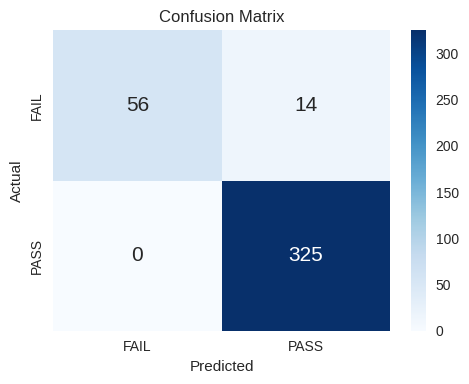

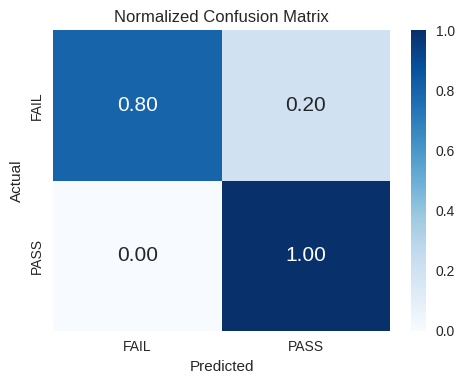

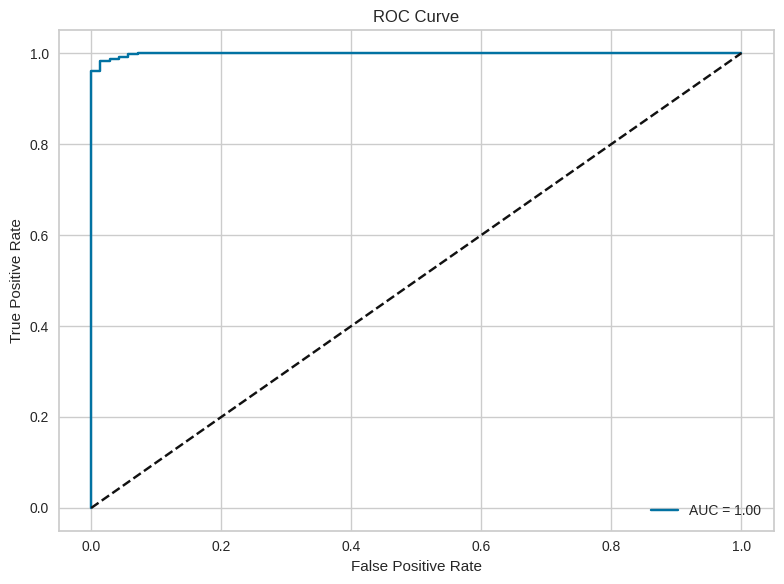


ROC-AUC: 0.9988

Model saved to: ../results/CatBoost_model.pkl

 EVALUATION: XGBoost
Accuracy      : 1.0000
Precision (W) : 1.0000
Recall (W)    : 1.0000
F1-score (W)  : 1.0000
Precision (M) : 1.0000
Recall (M)    : 1.0000
F1-score (M)  : 1.0000
Kappa         : 1.0000
MCC           : 1.0000

Classification Report:
              precision    recall  f1-score   support

        FAIL     1.0000    1.0000    1.0000        70
        PASS     1.0000    1.0000    1.0000       325

    accuracy                         1.0000       395
   macro avg     1.0000    1.0000    1.0000       395
weighted avg     1.0000    1.0000    1.0000       395



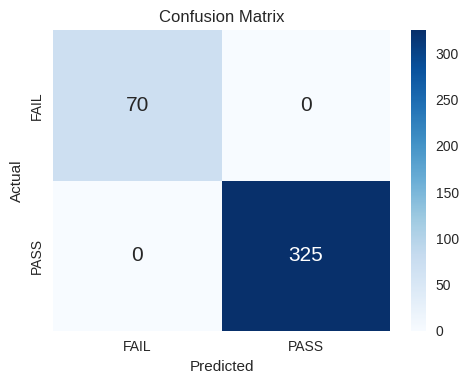

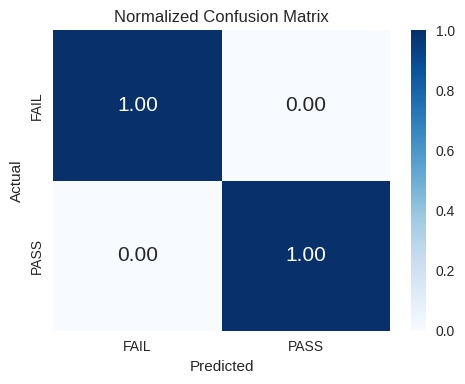

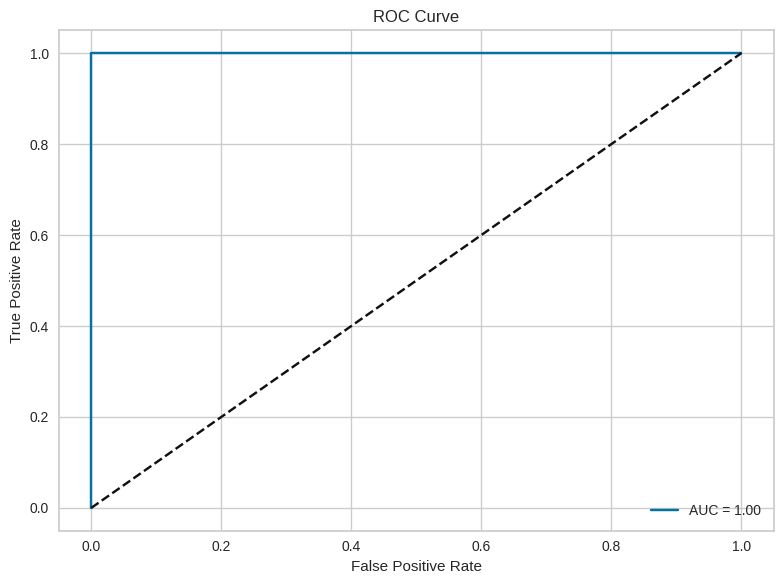


ROC-AUC: 1.0000

Model saved to: ../results/XGBoost_model.pkl

 EVALUATION: LightGBM
Accuracy      : 0.9924
Precision (W) : 0.9925
Recall (W)    : 0.9924
F1-score (W)  : 0.9923
Precision (M) : 0.9954
Recall (M)    : 0.9786
F1-score (M)  : 0.9868
Kappa         : 0.9735
MCC           : 0.9739

Classification Report:
              precision    recall  f1-score   support

        FAIL     1.0000    0.9571    0.9781        70
        PASS     0.9909    1.0000    0.9954       325

    accuracy                         0.9924       395
   macro avg     0.9954    0.9786    0.9868       395
weighted avg     0.9925    0.9924    0.9923       395



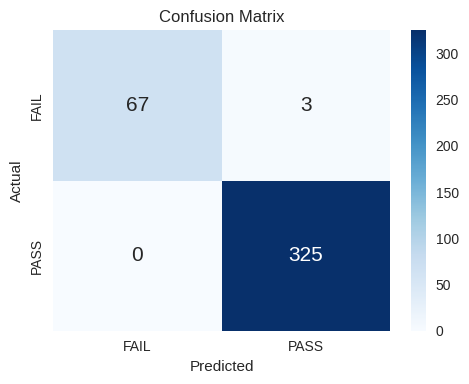

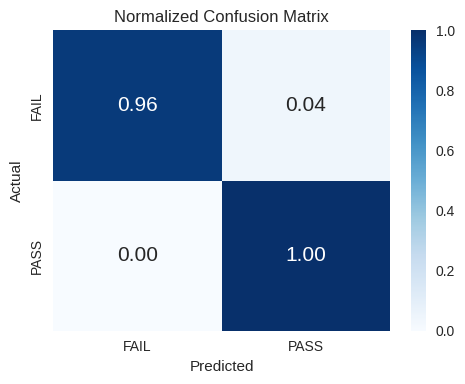

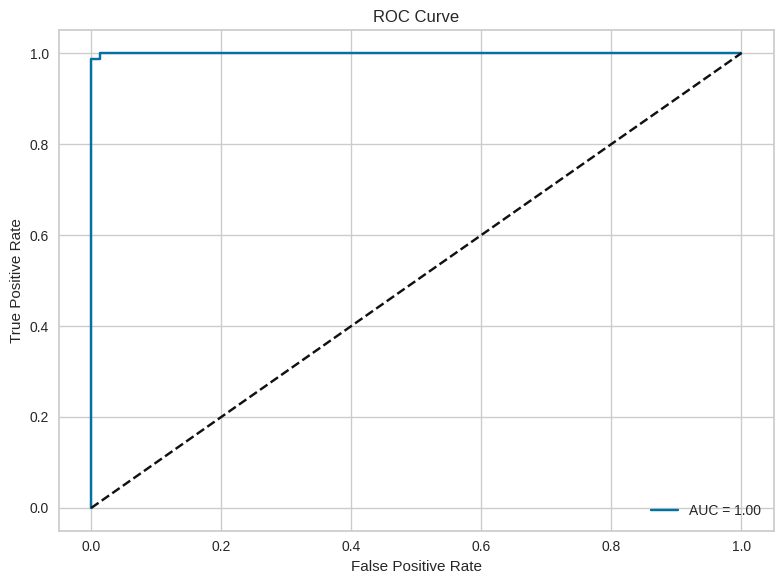


ROC-AUC: 0.9998

Model saved to: ../results/LightGBM_model.pkl

 EVALUATION: AdaBoost
Accuracy      : 0.8532
Precision (W) : 0.8358
Recall (W)    : 0.8532
F1-score (W)  : 0.8299
Precision (M) : 0.7776
Recall (M)    : 0.6418
F1-score (M)  : 0.6735
Kappa         : 0.3602
MCC           : 0.3968

Classification Report:
              precision    recall  f1-score   support

        FAIL     0.6875    0.3143    0.4314        70
        PASS     0.8678    0.9692    0.9157       325

    accuracy                         0.8532       395
   macro avg     0.7776    0.6418    0.6735       395
weighted avg     0.8358    0.8532    0.8299       395



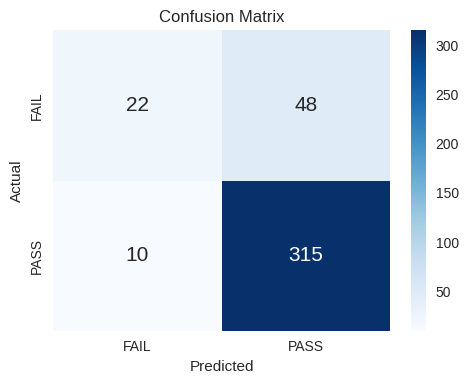

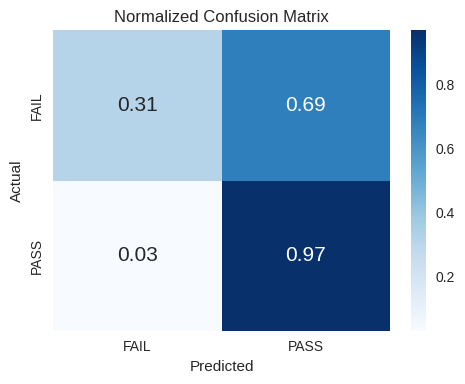

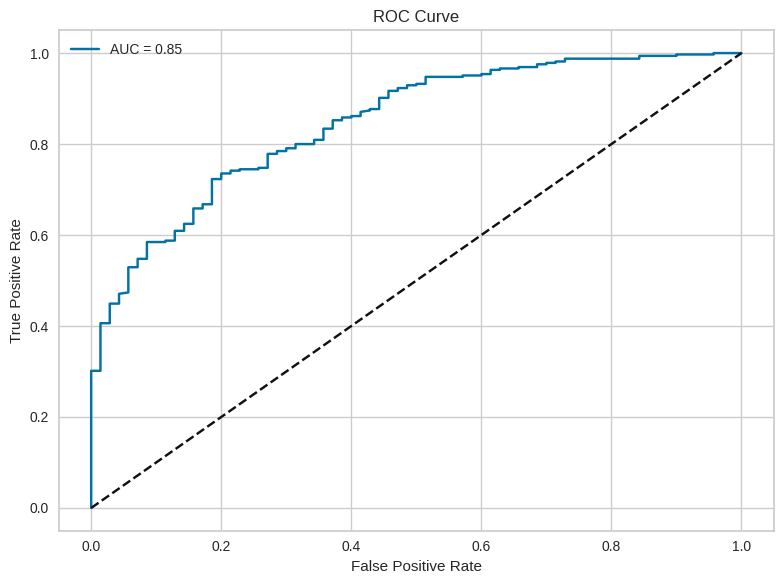


ROC-AUC: 0.8466

Model saved to: ../results/AdaBoost_model.pkl

 EVALUATION: RandomForest
Accuracy      : 1.0000
Precision (W) : 1.0000
Recall (W)    : 1.0000
F1-score (W)  : 1.0000
Precision (M) : 1.0000
Recall (M)    : 1.0000
F1-score (M)  : 1.0000
Kappa         : 1.0000
MCC           : 1.0000

Classification Report:
              precision    recall  f1-score   support

        FAIL     1.0000    1.0000    1.0000        70
        PASS     1.0000    1.0000    1.0000       325

    accuracy                         1.0000       395
   macro avg     1.0000    1.0000    1.0000       395
weighted avg     1.0000    1.0000    1.0000       395



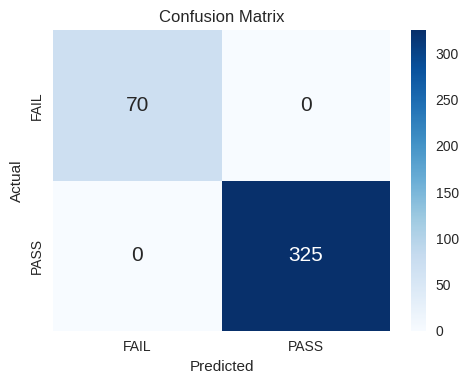

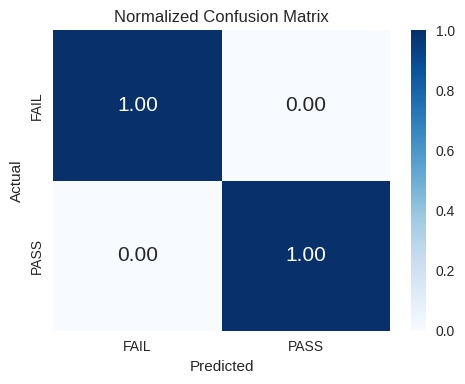

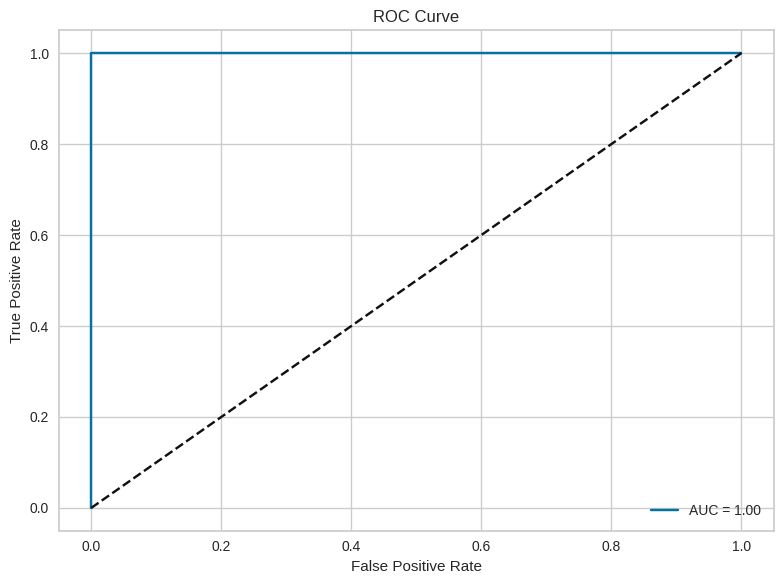


ROC-AUC: 1.0000

Model saved to: ../results/RandomForest_model.pkl


In [252]:
models_to_eval = {

    "CatBoost": models["CatBoost"],
    "XGBoost": models["XGBoost"],
    "LightGBM": models["LightGBM"],
    "AdaBoost": models["AdaBoost"],
    "RandomForest": models["RandomForest"]

}

for name, model in models_to_eval.items():

    evaluate_model(
        model=model,
        X_test=X_test,
        y_test=y_test,
        results_dir="../results/",
        name=name,
        class_names=label_encoders["final_grade"].classes_
    )



 EVALUATION: ensemble_model
Accuracy      : 0.9949
Precision (W) : 0.9950
Recall (W)    : 0.9949
F1-score (W)  : 0.9949
Precision (M) : 0.9969
Recall (M)    : 0.9857
F1-score (M)  : 0.9912
Kappa         : 0.9824
MCC           : 0.9826

Classification Report:
              precision    recall  f1-score   support

        FAIL     1.0000    0.9714    0.9855        70
        PASS     0.9939    1.0000    0.9969       325

    accuracy                         0.9949       395
   macro avg     0.9969    0.9857    0.9912       395
weighted avg     0.9950    0.9949    0.9949       395



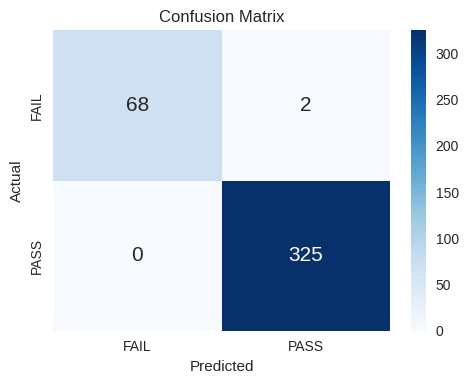

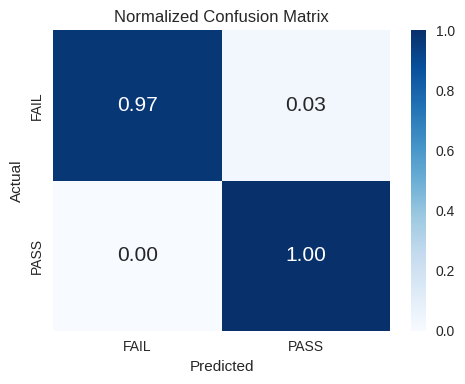

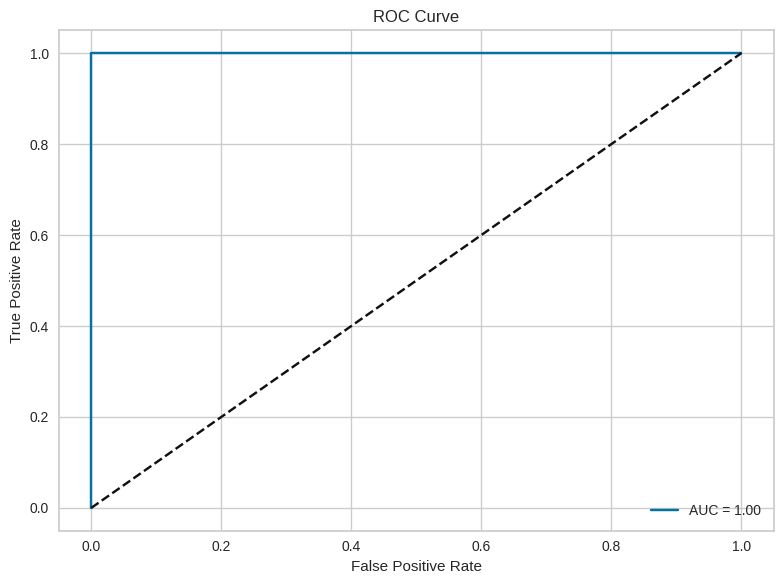


ROC-AUC: 1.0000

Model saved to: ../results/ensemble_model_model.pkl


In [253]:
import numpy as np

evaluate_model(
        model=ensemble_model,
        X_test=X_test,
        y_test=y_test,
        results_dir="../results/",
        name="ensemble_model",
        class_names=label_encoders["final_grade"].classes_
    )